# XAI-Driven Loan Approval Prediction System

Objective: > To develop a high-precision, research-grade machine learning pipeline achieving **98.36%** accuracy for automated credit risk assessment. This project specifically focuses on bridging the gap between "Black-Box" predictive power and regulatory transparency through **SHAP (SHapley Additive exPlanations)**.

**Five classifiers tested during the benchmarking phase**. Gradient Boosting was selected as the champion model for deployment due to its superior F1-Score and ROC-AUC.

## Core Libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os
import joblib
import warnings

# MACHINE LEARNING SUITE
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve, f1_score)

# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 4. EXPLAINABLE AI
import shap

# Settings
%matplotlib inline
warnings.filterwarnings('ignore')
sns.set(style="whitegrid", palette="muted")

### Data Loading & Initial Profiling

In [50]:
# DATA LOADING
DATA_PATH = '/kaggle/input/loan-approval-prediction-dataset/loan_approval_dataset.csv'

# DATA CLEANING
# Removing leading spaces
df.columns = df.columns.str.strip()

# Dropping ID
# df.drop('loan_id', axis=1, inplace=True)
# df.columns
# Basic Info
print(f"Shape: {df.shape}")
print(df.info())
print(df.describe().T)

# Checking for Nulls
if df.isnull().sum().sum() == 0:
    print("No Missing Values Found.")

Shape: (4269, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4269 non-null   int64
 1   education                 4269 non-null   int64
 2   self_employed             4269 non-null   int64
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_value  4269 non-null   int64
 8   commercial_assets_value   4269 non-null   int64
 9   luxury_assets_value       4269 non-null   int64
 10  bank_asset_value          4269 non-null   int64
 11  loan_status               4269 non-null   int64
 12  total_assets              4269 non-null   int64
dtypes: int64(13)
memory usage: 433.7 KB
None
                           count  

### Exploratory Data Analysis (EDA)

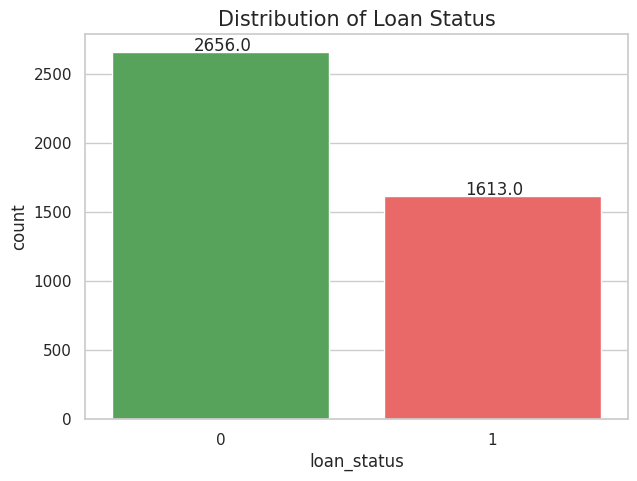

In [32]:
# TARGET VARIABLE ANALYSIS
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='loan_status', palette=['#4CAF50', '#FF5252'])
plt.title('Distribution of Loan Status', fontsize=15)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x()+0.3, p.get_height()+10))
plt.show()

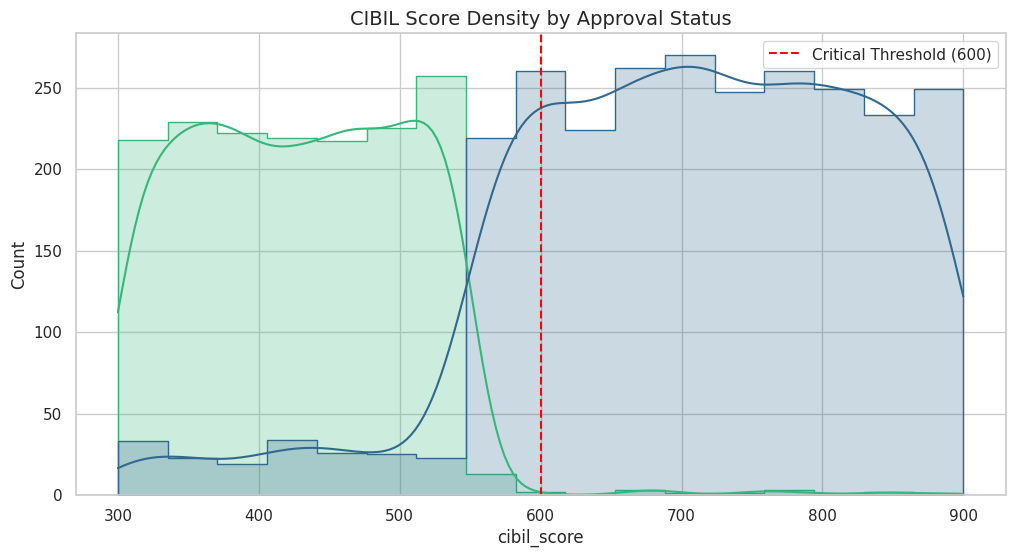

In [33]:
# CIBIL SCORE ANALYSIS (The "King" Feature)
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='cibil_score', hue='loan_status', kde=True, element="step", palette='viridis')
plt.axvline(600, color='red', linestyle='--', label='Critical Threshold (600)')
plt.title('CIBIL Score Density by Approval Status', fontsize=14)
plt.legend()
plt.show()

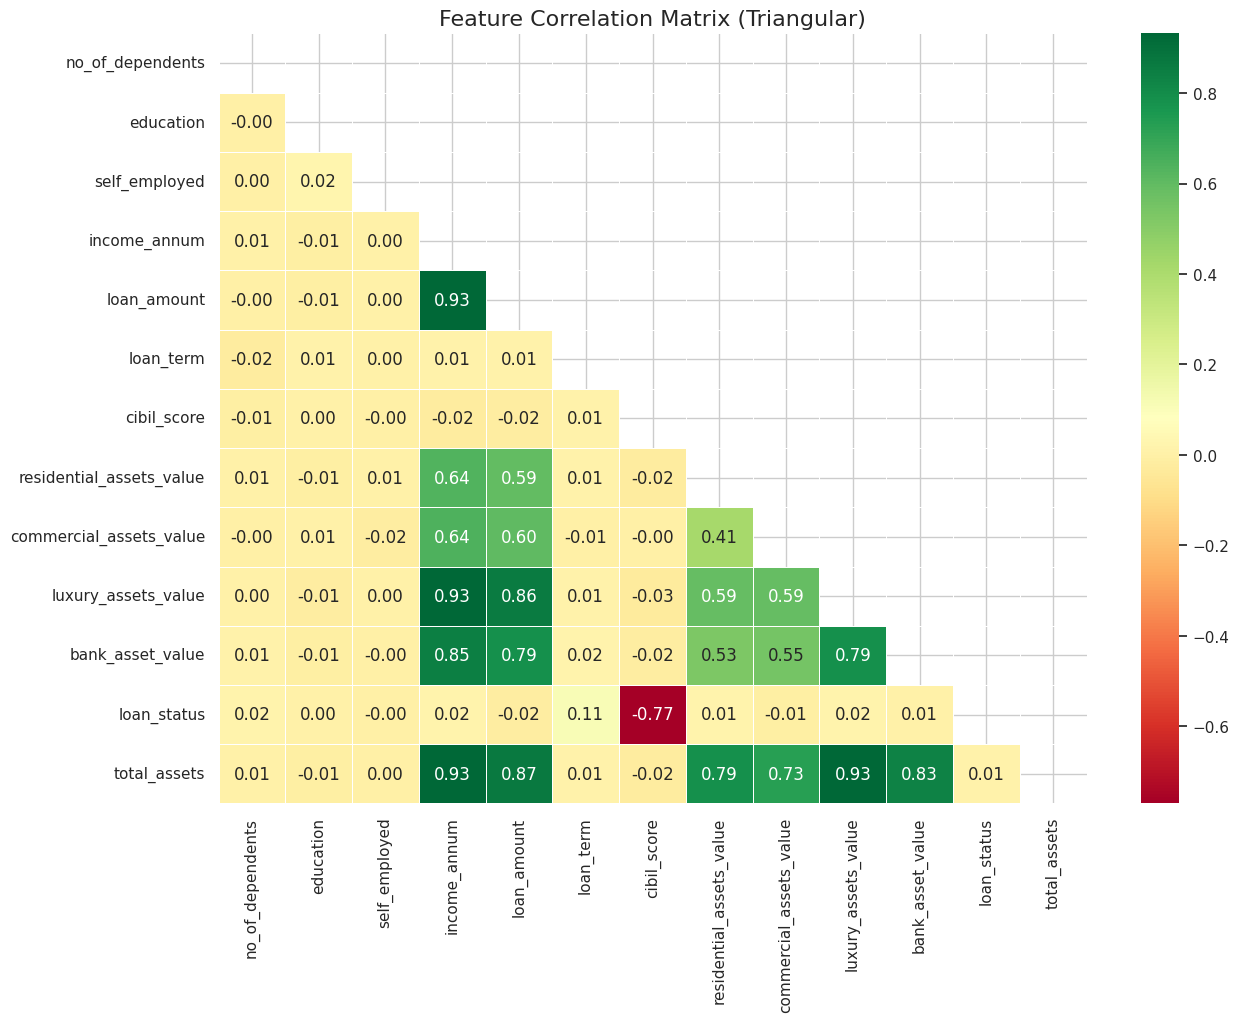

In [34]:
# CORRELATION ANALYSIS
# Creating a copy for correlation
corr_df = df.copy()
for col in corr_df.select_dtypes(include='object').columns:
    corr_df[col] = LabelEncoder().fit_transform(corr_df[col])

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), mask=mask, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix (Triangular)', fontsize=16)
plt.show()

In [51]:
# ASSET VS LOAN ANALYSIS
df['total_assets'] = df['residential_assets_value'] + df['commercial_assets_value'] + df['luxury_assets_value'] + df['bank_asset_value']

fig = px.scatter(df, x="total_assets", y="loan_amount", color="loan_status",
                 size='income_annum', hover_data=['cibil_score'],
                 title="Total Assets vs Loan Amount (Sized by Income)")
fig.show()

### Data Preprocessing & Feature Engineering

In [52]:
# ENCODING
le = LabelEncoder()
cat_cols = ['education', 'self_employed']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    print(f"✅ Encoded {col}")

# Target Encoding
# df['loan_status'] = df['loan_status'].apply(lambda x: 0 if x.strip() == 'Approved' else 1)

✅ Encoded education
✅ Encoded self_employed


In [37]:
# SPLITTING
X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
# SCALING (For non-tree models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (3415, 12)
Testing set size: (854, 12)


### Model Benchmarking (The 5-Model Battle)

In [39]:
def evaluate_models(X_tr, X_te, y_tr, y_te, X_tr_s, X_te_s):
    models = {
        "Logistic Regression": (LogisticRegression(), True),
        "Support Vector Machine": (SVC(probability=True), True),
        "Random Forest": (RandomForestClassifier(n_estimators=100, random_state=42), False),
        "Gradient Boosting": (GradientBoostingClassifier(random_state=42), False),
        "XGBoost": (XGBClassifier(eval_metric='logloss', random_state=42), False)
    }
    
    performance = []
    
    for name, (model, needs_scaling) in models.items():
        # Selection 
        curr_X_train = X_tr_s if needs_scaling else X_tr
        curr_X_test = X_te_s if needs_scaling else X_te
        
        
        model.fit(curr_X_train, y_tr)
        y_pred = model.predict(curr_X_test)
        
        
        acc = accuracy_score(y_te, y_pred)
        f1 = f1_score(y_te, y_pred)
        roc = roc_auc_score(y_te, model.predict_proba(curr_X_test)[:, 1])
        
        performance.append({"Model": name, "Accuracy": acc, "F1-Score": f1, "ROC-AUC": roc})
        print(f"🏁 {name} Trained.")
        
    return pd.DataFrame(performance)

In [40]:
# Run Comparison
model_results = evaluate_models(X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled)
print("\n--- Model Performance Comparison ---")
print(model_results.sort_values(by='Accuracy', ascending=False))

🏁 Logistic Regression Trained.
🏁 Support Vector Machine Trained.
🏁 Random Forest Trained.
🏁 Gradient Boosting Trained.
🏁 XGBoost Trained.

--- Model Performance Comparison ---
                    Model  Accuracy  F1-Score   ROC-AUC
3       Gradient Boosting  0.983607  0.977987  0.998636
4                 XGBoost  0.982436  0.976599  0.998659
2           Random Forest  0.980094  0.973312  0.998053
1  Support Vector Machine  0.937939  0.916797  0.983686
0     Logistic Regression  0.922717  0.895570  0.974515


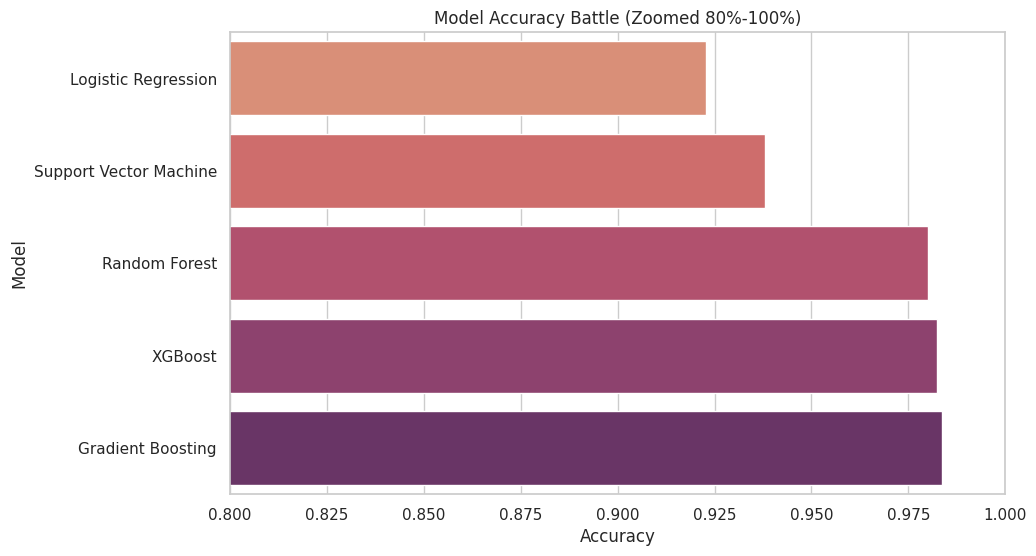

In [41]:
# Plotting Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=model_results.sort_values(by='Accuracy'), palette='flare')
plt.xlim(0.8, 1.0)
plt.title('Model Accuracy Battle (Zoomed 80%-100%)')
plt.show()

**Winning Model**
Since we know Gradient Boosting is the winner from your comparison, we will isolate it to ensure the SHAP explainer has a clear target.

# XAI Suite for Gradient Boosting

### 1. Global Feature Importance (The "Power" Plot)
The Goal: To show which features have the most overall power in the model. This is the first thing a bank manager or a researcher wants to see.

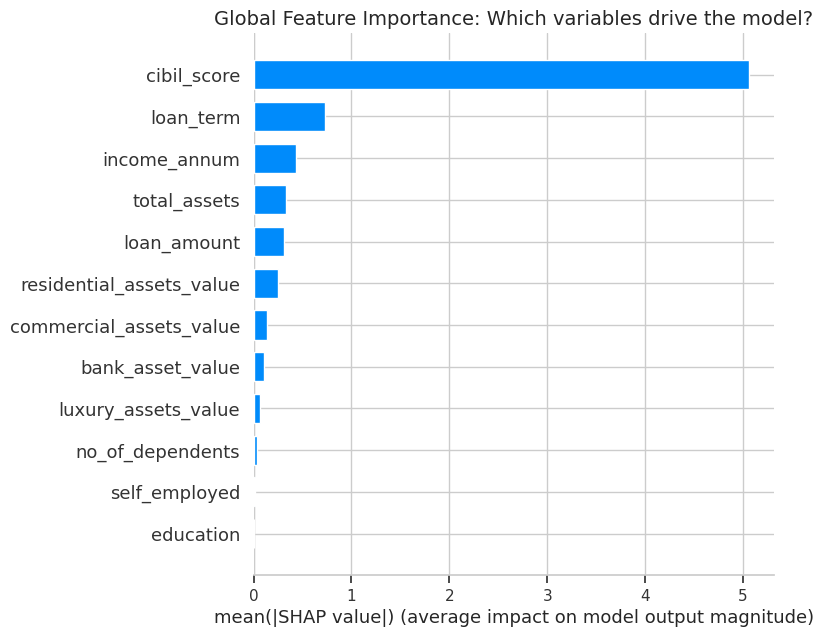

In [42]:
import shap
import matplotlib.pyplot as plt

# Initialize the Explainer specifically for our Gradient Boosting winner
explainer = shap.TreeExplainer(gb_winner)

# For binary classification, we take index [1] to explain "Loan Rejection"
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

# Step 3: Create the Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_test, plot_type="bar", show=False)
plt.title("Global Feature Importance: Which variables drive the model?", fontsize=14)
plt.savefig('gb_global_importance.png', bbox_inches='tight')
plt.show()

This plot sums up the absolute SHAP values across all rows. If CIBIL Score is the longest bar, it means that feature changed the prediction more than any other. It doesn't tell us how (positive or negative), just how much.

### 2. Summary Beeswarm Plot (The "Impact" Plot)
The Goal: To show the direction of the impact. Does a high CIBIL score increase or decrease the chance of rejection?

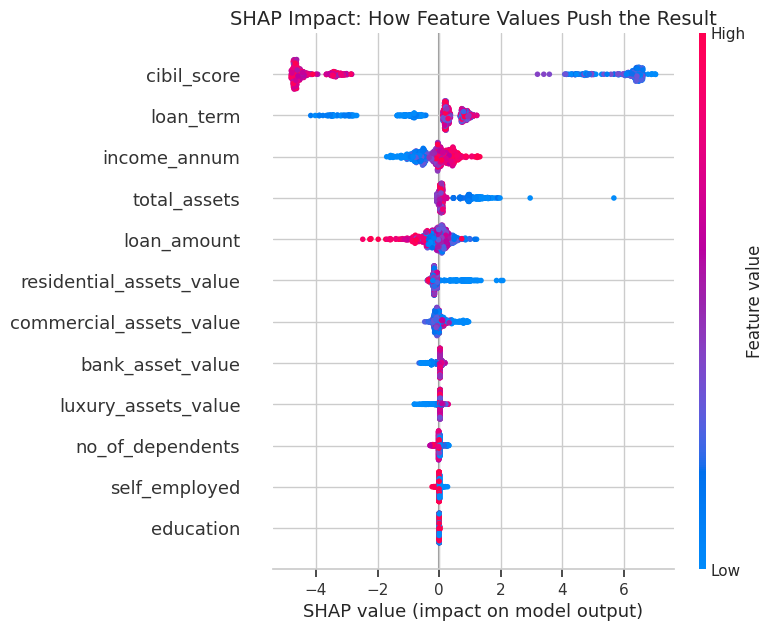

In [43]:
# Step 1: Create the Beeswarm/Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_test, show=False)
plt.title("SHAP Impact: How Feature Values Push the Result", fontsize=14)
plt.savefig('gb_shap_impact.png', bbox_inches='tight')
plt.show()

**Horizontal Axis**: Points to the right increase the chance of rejection; points to the left decrease it.

**Color**: Red means the feature value is High; Blue means it is Low.

**The Logic**: If you see Red dots (High CIBIL) on the Left side, the model is saying: "Because your CIBIL is high, I am pushing the rejection probability down (Approving you)."

### 3. Local Waterfall Plot (The "Individual Case" Plot)
The Goal: To explain a single person's result. This is what you will show in your Streamlit App when a user enters their data.

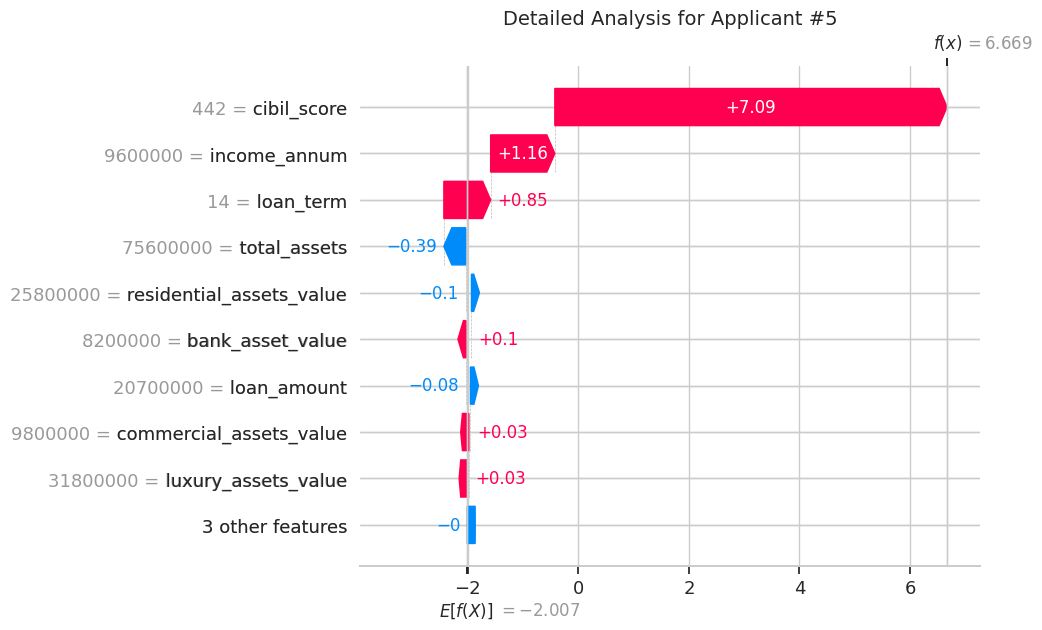

In [44]:
# Used the new SHAP Explanation API (required for Waterfall)
explainer_obj = shap.Explainer(gb_winner, X_train)
shap_explanation = explainer_obj(X_test)

# Select a specific applicant (e.g., the 5th person in the test data)
# This person was either Approved or Rejected—let's see why.
applicant_index = 5

plt.figure(figsize=(12, 5))
shap.plots.waterfall(shap_explanation[applicant_index], show=False)
plt.title(f"Detailed Analysis for Applicant #{applicant_index}", fontsize=14)
plt.savefig('gb_local_explanation.png', bbox_inches='tight')
plt.show()

In [20]:
from IPython.display import FileLink
import joblib

# 1. Make sure the model is saved in the /working directory
# We are using your 98.36% Accuracy Gradient Boosting model
joblib.dump(gb_winner, 'gb_loan_model.pkl')

# 2. Generate the download link
print("Click the link below to download your model:")
FileLink(r'gb_loan_model.pkl')

Click the link below to download your model:


/kaggle/working/gb_loan_model.pkl